# Linear Regression — California Housing Dataset
Full workflow: data loading → EDA → preprocessing → training → evaluation → visualization

In [1]:
!pip install pandas matplotlib seaborn

zsh:1: command not found: pip


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn import metrics

sns.set_theme(style='whitegrid')
print('All imports successful')

Matplotlib is building the font cache; this may take a moment.


All imports successful


## 1. Load Data

In [4]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame
print(f'Shape: {df.shape}')
df.head()

Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## 2. Exploratory Data Analysis

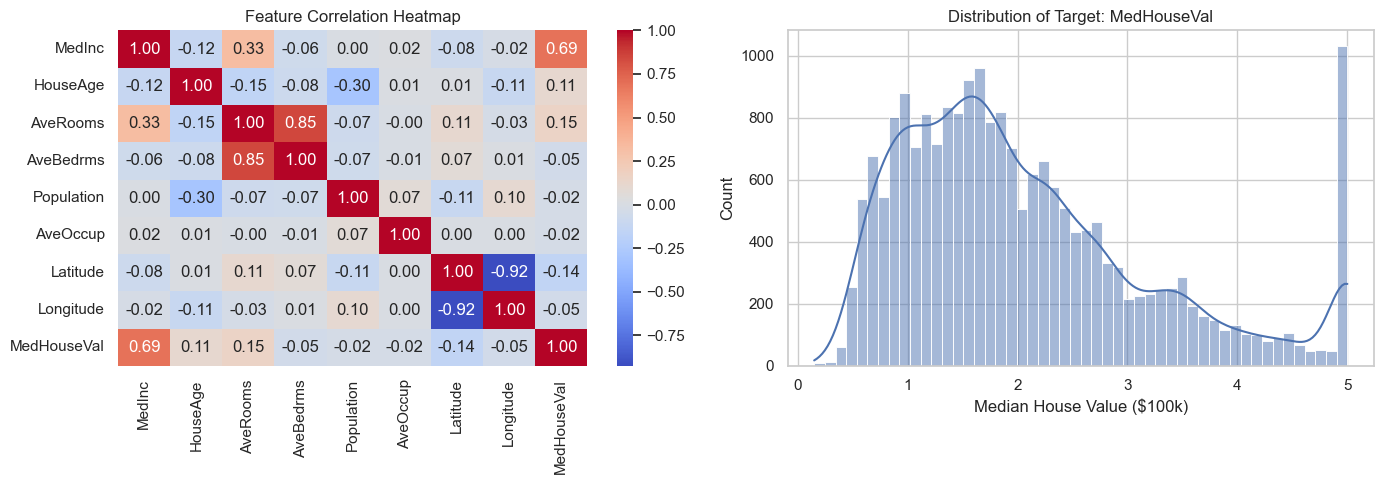

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlation heatmap
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[0])
axes[0].set_title('Feature Correlation Heatmap')

# Target distribution
sns.histplot(df['MedHouseVal'], bins=50, kde=True, ax=axes[1])
axes[1].set_title('Distribution of Target: MedHouseVal')
axes[1].set_xlabel('Median House Value ($100k)')

plt.tight_layout()
plt.show()

## 3. Preprocessing

In [7]:
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Train samples: {X_train_scaled.shape[0]}')
print(f'Test samples:  {X_test_scaled.shape[0]}')

Train samples: 16512
Test samples:  4128


## 4. Train the Model

In [8]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
coef_df = coef_df.sort_values('Coefficient', key=abs, ascending=False)
print(f'Intercept: {model.intercept_:.4f}\n')
coef_df

Intercept: 2.0719



,Feature,Coefficient
6,Latitude,-0.896929
7,Longitude,-0.869842
0,MedInc,0.854383
3,AveBedrms,0.339259
2,AveRooms,-0.294410
1,HouseAge,0.122546
5,AveOccup,-0.040829
4,Population,-0.002308


## 5. Predict & Evaluate

In [9]:
y_pred = model.predict(X_test_scaled)

mae  = metrics.mean_absolute_error(y_test, y_pred)
mse  = metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = metrics.r2_score(y_test, y_pred)

print('=== Test Set Metrics ===')
print(f'  MAE  : {mae:.4f}')
print(f'  MSE  : {mse:.4f}')
print(f'  RMSE : {rmse:.4f}')
print(f'  R²   : {r2:.4f}')

=== Test Set Metrics ===
  MAE  : 0.5332
  MSE  : 0.5559
  RMSE : 0.7456
  R²   : 0.5758


/Users/sameer/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/sameer/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/sameer/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


## 6. Visualize Results

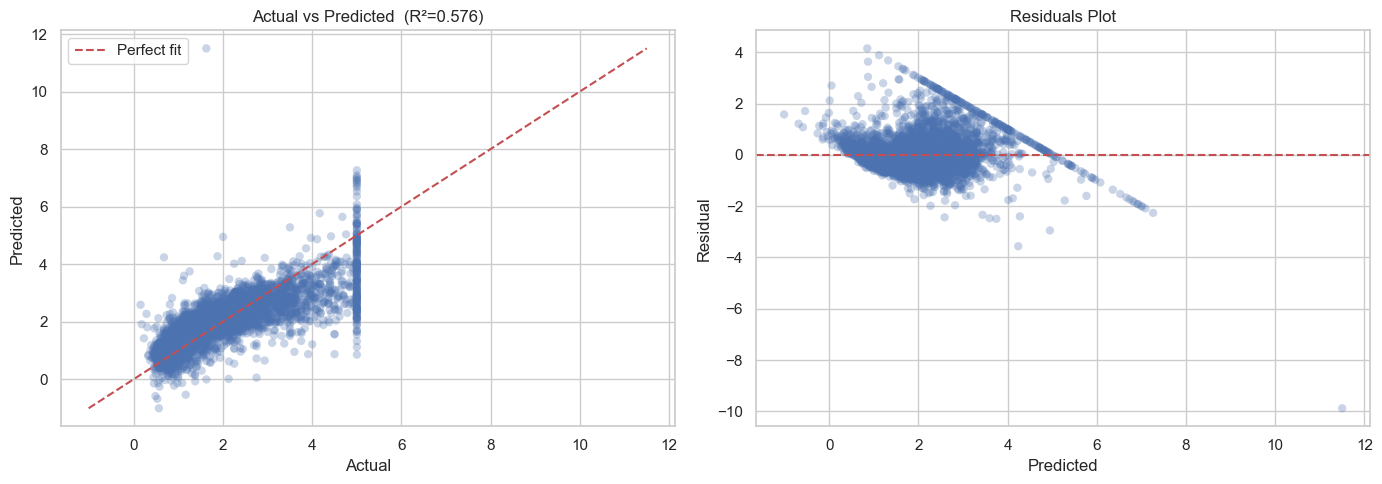

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.3, edgecolors='none')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title(f'Actual vs Predicted  (R²={r2:.3f})')
axes[0].legend()

# Residuals
residuals = y_test.values - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.3, edgecolors='none')
axes[1].axhline(0, color='r', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residuals Plot')

plt.tight_layout()
plt.show()